In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/intents_for_colab.csv'

Loading Dataset

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f"Original dataset size: {len(df)}")
print("Columns:", df.columns.tolist())
print(df.head())

Original dataset size: 997
Columns: ['message', 'label']
                           message      label
0                    can you help?       help
1                  feedback option   feedback
2           sign out of educonnect     logout
3             study materials list  resources
4  how do i sign in to educonnect?      login


Cleaning Dataset

In [ ]:
# Ensure required columns exist
if 'message' not in df.columns or 'label' not in df.columns:
    raise ValueError("CSV must have columns 'message' and 'label'")

# Basic cleaning
df.dropna(subset=['message', 'label'], inplace=True)
df['message'] = df['message'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip().str.lower()
df = df[(df['message'].str.len() > 0) & (df['label'].str.len() > 0)]
df.drop_duplicates(subset=['message', 'label'], inplace=True)

print(f"After cleaning: {len(df)} rows")

After cleaning: 993 rows


In [ ]:
label_counts = df['label'].value_counts()

print(f"Number of unique intents: {len(label_counts)}")
print(label_counts)

Number of unique intents: 18
label
nlp_insights       68
help               65
admin              64
logout             63
chat               58
analytics          57
recommendations    57
resources          56
quiz               55
feedback           52
signup             52
study_group        51
login              51
timer              51
next_topic         51
profile            49
password_reset     48
dashboard          45
Name: count, dtype: int64


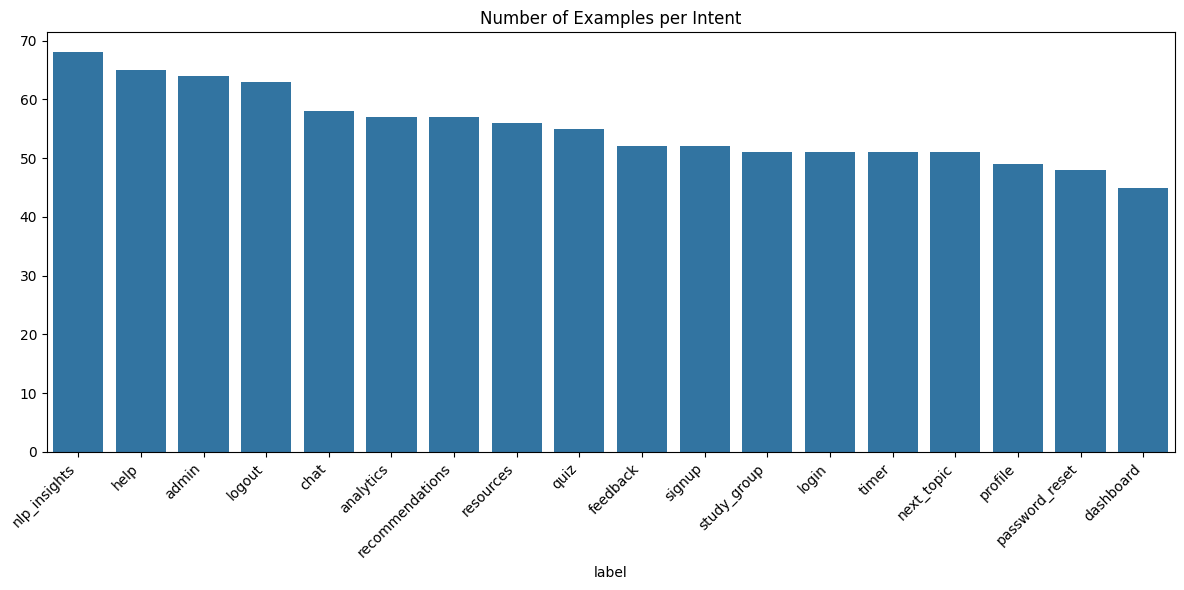

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Examples per Intent')
plt.tight_layout()
plt.show()

count    993.000000
mean      16.265861
std        4.712267
min        3.000000
25%       13.000000
50%       16.000000
75%       19.000000
max       36.000000
Name: msg_len, dtype: float64


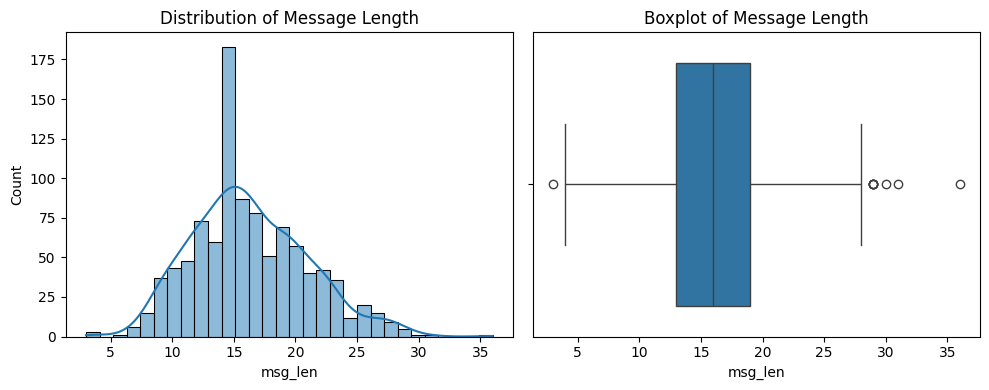

In [ ]:
df['msg_len'] = df['message'].apply(len)

print(df['msg_len'].describe())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['msg_len'], bins=30, kde=True)
plt.title('Distribution of Message Length')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['msg_len'])
plt.title('Boxplot of Message Length')

plt.tight_layout()
plt.show()

Encoding labels

In [ ]:
unique_labels = df['label'].unique().tolist()
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

df['label_id'] = df['label'].map(label2id)

print("Label mapping:")
print(label2id)

Label mapping:
{'help': 0, 'feedback': 1, 'logout': 2, 'resources': 3, 'login': 4, 'signup': 5, 'quiz': 6, 'chat': 7, 'timer': 8, 'study_group': 9, 'dashboard': 10, 'analytics': 11, 'profile': 12, 'admin': 13, 'next_topic': 14, 'password_reset': 15, 'nlp_insights': 16, 'recommendations': 17}


Splitting the data

In [ ]:
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.1

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df['label_id'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VALIDATION_SIZE,
    stratify=train_val_df['label_id'],
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 714
Validation size: 80
Test size: 199


Saving Split data

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/intent_project_prepared'

import os
os.makedirs(SAVE_DIR, exist_ok=True)

train_df.to_csv(f'{SAVE_DIR}/train.csv', index=False)
val_df.to_csv(f'{SAVE_DIR}/val.csv', index=False)
test_df.to_csv(f'{SAVE_DIR}/test.csv', index=False)

pd.DataFrame({
    'label': list(label2id.keys()),
    'label_id': list(label2id.values())
}).to_csv(f'{SAVE_DIR}/label_mapping.csv', index=False)

print("Prepared files saved successfully.")

Prepared files saved successfully.


In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = '/content/drive/MyDrive/intent_project_prepared'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df = pd.read_csv(f'{DATA_DIR}/val.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test.csv')
label_map_df = pd.read_csv(f'{DATA_DIR}/label_mapping.csv')

unique_labels = label_map_df.sort_values('label_id')['label'].tolist()

print(train_df.head())
print(unique_labels)

                        message           label  msg_len  label_id
0  i can't remember my password  password_reset       28        15
1                update profile         profile       14        12
2             set a study timer           timer       17         8
3                main page link       dashboard       14        10
4                     set timer           timer        9         8
['help', 'feedback', 'logout', 'resources', 'login', 'signup', 'quiz', 'chat', 'timer', 'study_group', 'dashboard', 'analytics', 'profile', 'admin', 'next_topic', 'password_reset', 'nlp_insights', 'recommendations']


Building the baseline pipeline

In [ ]:
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=5000
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

Define hyperparameter grid

In [ ]:
param_grid = {
    'tfidf__lowercase': [True],
    'tfidf__stop_words': [None, 'english'],
    'tfidf__max_features': [3000, 5000, 8000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__max_iter': [1000, 2000],
    'clf__class_weight': [None, 'balanced'],
    'clf__solver': ['liblinear', 'lbfgs']
}

Run grid Search on training data

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define pipeline
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=42))
])

# Define parameter grid
param_grid = {
    'tfidf__stop_words': [None, 'english'],
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__class_weight': [None, 'balanced'],
    'clf__max_iter': [1000]
}

# Create and run GridSearch (TRAINING)
grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    refit=True
)

grid_search.fit(train_df['message'], train_df['label_id'])

# Best trained model
best_baseline_model = grid_search.best_estimator_

Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Validation
val_preds = best_baseline_model.predict(val_df['message'])

print("Validation Accuracy:", accuracy_score(val_df['label_id'], val_preds))
print("Validation F1:", f1_score(val_df['label_id'], val_preds, average='weighted'))
print(classification_report(val_df['label_id'], val_preds, target_names=unique_labels))

Validation Accuracy: 0.925
Validation F1: 0.9241477272727273
                 precision    recall  f1-score   support

           help       0.67      0.80      0.73         5
       feedback       0.75      0.75      0.75         4
         logout       1.00      1.00      1.00         5
      resources       1.00      1.00      1.00         5
          login       0.80      1.00      0.89         4
         signup       1.00      1.00      1.00         4
           quiz       1.00      1.00      1.00         4
           chat       0.80      0.80      0.80         5
          timer       1.00      1.00      1.00         4
    study_group       1.00      1.00      1.00         4
      dashboard       1.00      1.00      1.00         4
      analytics       1.00      0.60      0.75         5
        profile       1.00      1.00      1.00         4
          admin       0.83      1.00      0.91         5
     next_topic       1.00      1.00      1.00         4
 password_reset       1.00

In [ ]:
# Test
test_preds = best_baseline_model.predict(test_df['message'])

print("Test Accuracy:", accuracy_score(test_df['label_id'], test_preds))
print("Test F1:", f1_score(test_df['label_id'], test_preds, average='weighted'))
print(classification_report(test_df['label_id'], test_preds, target_names=unique_labels))

Test Accuracy: 0.9547738693467337
Test F1: 0.9538483685129959
                 precision    recall  f1-score   support

           help       1.00      0.92      0.96        13
       feedback       0.91      1.00      0.95        10
         logout       1.00      1.00      1.00        13
      resources       0.91      0.91      0.91        11
          login       1.00      1.00      1.00        10
         signup       1.00      1.00      1.00        10
           quiz       1.00      1.00      1.00        11
           chat       1.00      1.00      1.00        12
          timer       1.00      1.00      1.00        10
    study_group       0.90      0.90      0.90        10
      dashboard       1.00      1.00      1.00         9
      analytics       1.00      1.00      1.00        11
        profile       1.00      1.00      1.00        10
          admin       1.00      0.92      0.96        13
     next_topic       0.77      1.00      0.87        10
 password_reset       1.0

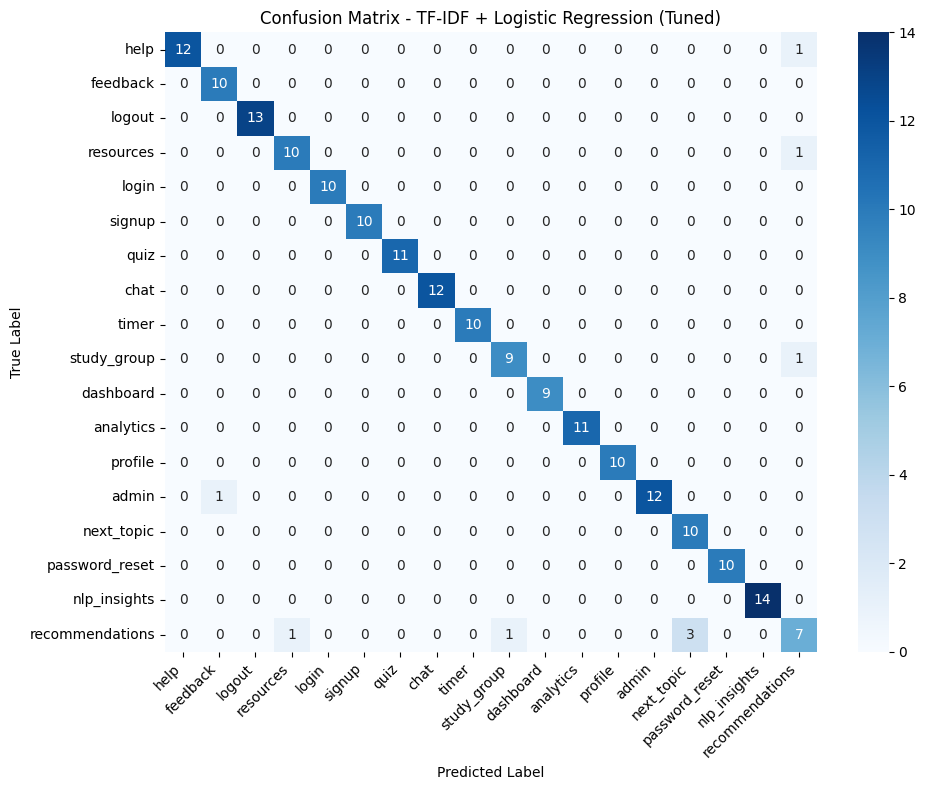

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions (use test set for final evaluation)
test_preds = best_baseline_model.predict(test_df['message'])

# Compute confusion matrix
cm = confusion_matrix(test_df['label_id'], test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=unique_labels,
    yticklabels=unique_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression (Tuned)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()